In [1]:
from auxiliary_functions import *

In [2]:
graph = nx.read_gexf("labeled_graph.gexf")
std_threshold = 0.5
NumberOfRandoms = 300

In [3]:
graphs = simplify_graph(graph, std_threshold)

# Generate null models for each subreddit graph
null_models = {}

for subreddit, subreddit_graph in graphs.items():
	# Create multiple randomized versions of each graph for statistical comparison
	null_models[subreddit] = [
		generate_null_model(subreddit_graph) 
		for _ in range(NumberOfRandoms)
	]

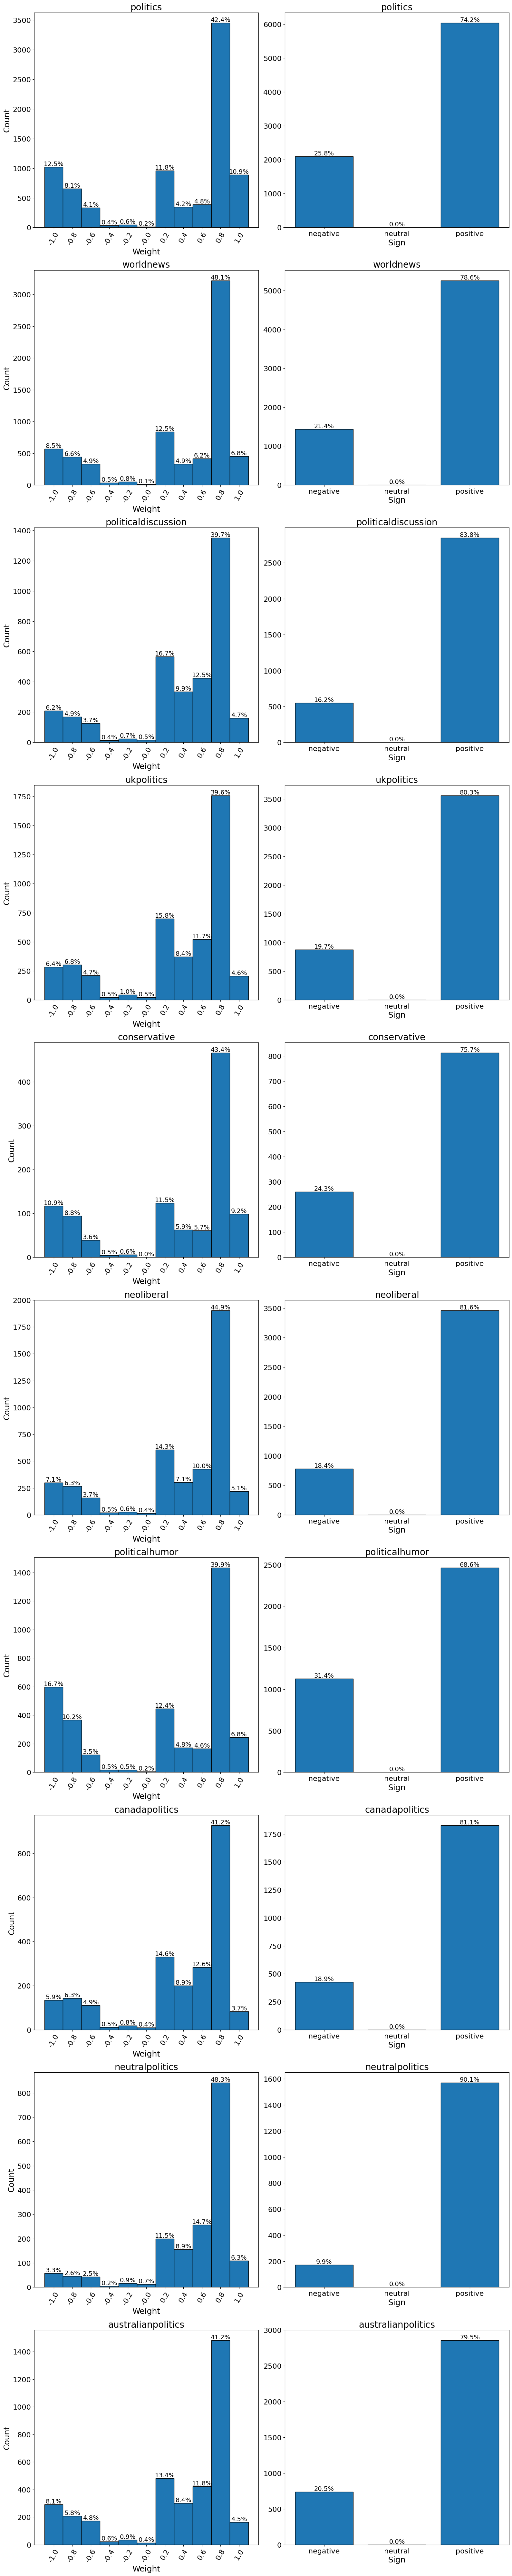

In [4]:
plot_weight_distribution(graphs)

In [5]:
triangles_graph = calculate_triangles_graph(graphs)

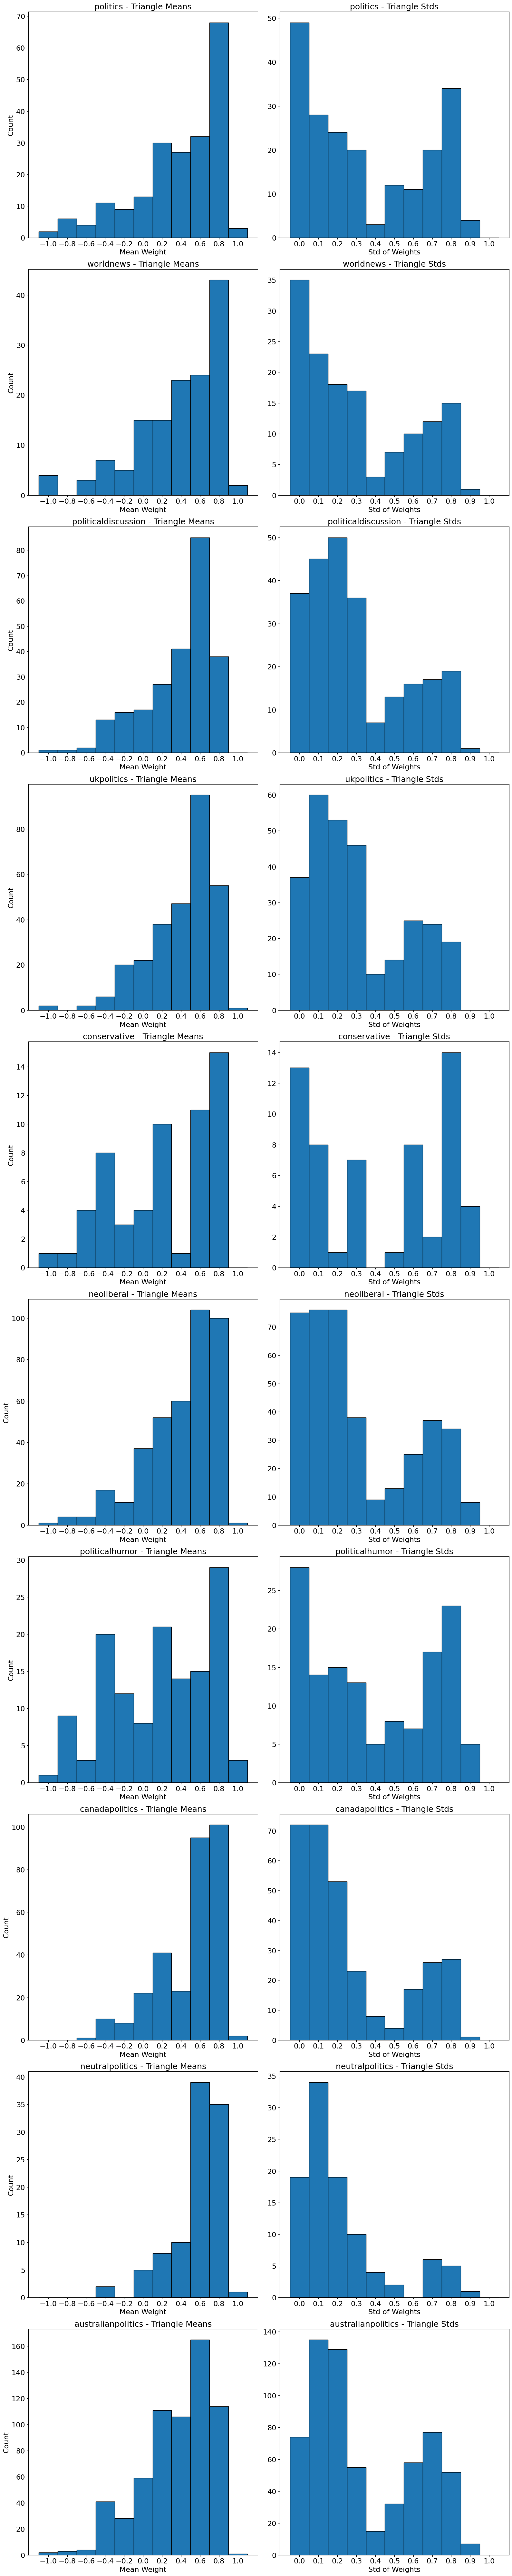

In [6]:
plot_triangle_distribution(graphs, triangles_graph)

In [7]:
df = number_of_triangles_per_type(graphs, triangles_graph)

df.to_csv('file.csv', index=True)

df

,0 pos edges,1 pos edge,2 pos edges,3 pos edges
politics,9,21,62,113
worldnews,6,10,40,85
politicaldiscussion,3,24,48,166
ukpolitics,3,24,67,194
conservative,2,14,15,27
neoliberal,6,29,100,256
politicalhumor,11,30,36,58
canadapolitics,0,16,68,219
neutralpolitics,0,3,15,82
australianpolitics,9,64,184,377


In [8]:
# IN DEVELOPMENT: NON_BINARY_METRIC

results_nb, distributions_nb = non_binary_metric(triangles_graph, calculate_triangles_null_graph(graphs, null_models))
results_nb

,prod,mean,std,z-score
subreddit,,,,
politics,0.061540,0.012850,0.025524,1.907628
worldnews,0.089190,0.022574,0.025262,2.636959
politicaldiscussion,0.081276,0.025417,0.015351,3.638732
ukpolitics,0.076475,0.019406,0.015236,3.745650
conservative,0.135232,0.013502,0.042478,2.865745
neoliberal,0.083202,0.027584,0.013823,4.023711
politicalhumor,0.098310,0.000934,0.031853,3.057088
canadapolitics,0.128910,0.021499,0.015184,7.074025
neutralpolitics,0.140683,0.081810,0.023894,2.463943


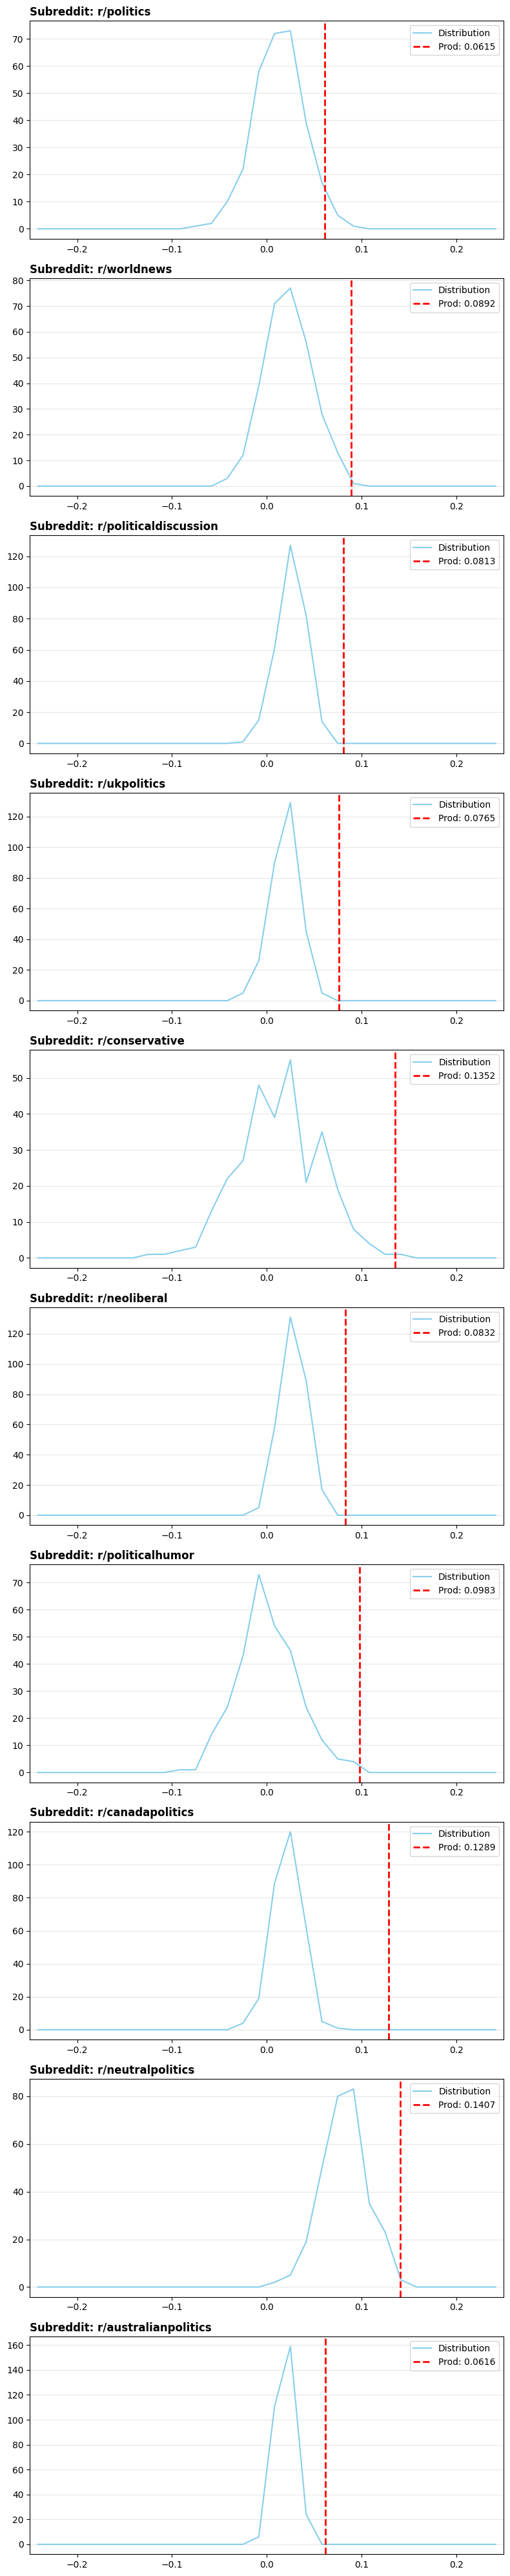

In [9]:
# 1. Create a figure with a subplot for each subreddit
num_subs = len(distributions_nb)
fig, axes = plt.subplots(num_subs, 1, figsize=(8, 4 * num_subs))

# Handle the case where there's only 1 subreddit (axes wouldn't be a list)
if num_subs == 1:
    axes = [axes]

for i, (subreddit, distribution) in enumerate(distributions_nb.items()):
    ax = axes[i]
    
    # 2. Calculate the histogram data manually to plot only the "top points"
    # We use density=True if you want the area to scale, or False for raw counts
    counts, bin_edges = np.histogram(distribution, bins=30, range=(-0.25, 0.25))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # 3. Plot the 'top points' as a step or line plot
    ax.plot(bin_centers, counts, color='skyblue', label='Distribution')
    
    # 4. Plot and highlight the specific 'prod' value
    prod_val = results_nb.loc[subreddit, "prod"]
    ax.axvline(prod_val, color='red', linestyle='--', linewidth=2, label=f'Prod: {prod_val:.4f}')
    
    # Formatting
    ax.set_title(f"Subreddit: r/{subreddit}", loc='left', fontweight='bold')
    ax.set_xlim(-0.25, 0.25)
    ax.legend(loc='upper right')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
results_b, distributions_b = calculate_balance_metrics(graphs, null_models, NumberOfRandoms)
results_b

Starting politics
Starting worldnews
Starting politicaldiscussion
Starting ukpolitics
Starting conservative
Starting neoliberal
Starting politicalhumor
Starting canadapolitics
Starting neutralpolitics
Starting australianpolitics


,B_w,mean,std,z-score
politics,0.006191,0.010313,0.001167,-3.531546
worldnews,0.021197,0.038599,0.004776,-3.643412
politicaldiscussion,0.012899,0.023987,0.002464,-4.498944
ukpolitics,0.016738,0.029209,0.002520,-4.949328
conservative,0.008455,0.014586,0.002890,-2.121330
neoliberal,0.017590,0.026864,0.002353,-3.941052
politicalhumor,0.008977,0.021720,0.003116,-4.089562
canadapolitics,0.011335,0.027895,0.003798,-4.360049
neutralpolitics,0.001428,0.002190,0.000402,-1.893238
australianpolitics,0.014914,0.023888,0.002162,-4.151658


In [16]:
distributions_b

[array([0.01182137, 0.01193763, 0.00971162, 0.01021866, 0.00966753,
        0.00908246, 0.00932771, 0.00872981, 0.00948783, 0.00913987,
        0.01096423, 0.01144396, 0.0091195 , 0.01144176, 0.00918532,
        0.01057922, 0.00951012, 0.01087827, 0.00979636, 0.00917088,
        0.01104685, 0.01012086, 0.00910936, 0.01023638, 0.00918692,
        0.01036313, 0.00859863, 0.01003652, 0.00802625, 0.011285  ,
        0.00761656, 0.00788568, 0.00859196, 0.01085554, 0.00844809,
        0.01086627, 0.00898679, 0.01097101, 0.00892033, 0.00820957,
        0.01044821, 0.00960905, 0.01022294, 0.00935737, 0.01011472,
        0.00988309, 0.00920698, 0.00946057, 0.01104988, 0.01196745,
        0.0116471 , 0.01288797, 0.00899372, 0.0106114 , 0.00996121,
        0.01172653, 0.01053755, 0.01093403, 0.0102107 , 0.00913853,
        0.01016973, 0.00931669, 0.00960932, 0.00899477, 0.01122651,
        0.00968264, 0.01018178, 0.00932718, 0.009524  , 0.00859101,
        0.01168538, 0.01107426, 0.00898392, 0.00

In [18]:
import json

LIST = [distributions_b[i].tolist() for i in range(len(distributions_b))]


with open("distributions_b", 'w') as f:
    json.dump(LIST, f)

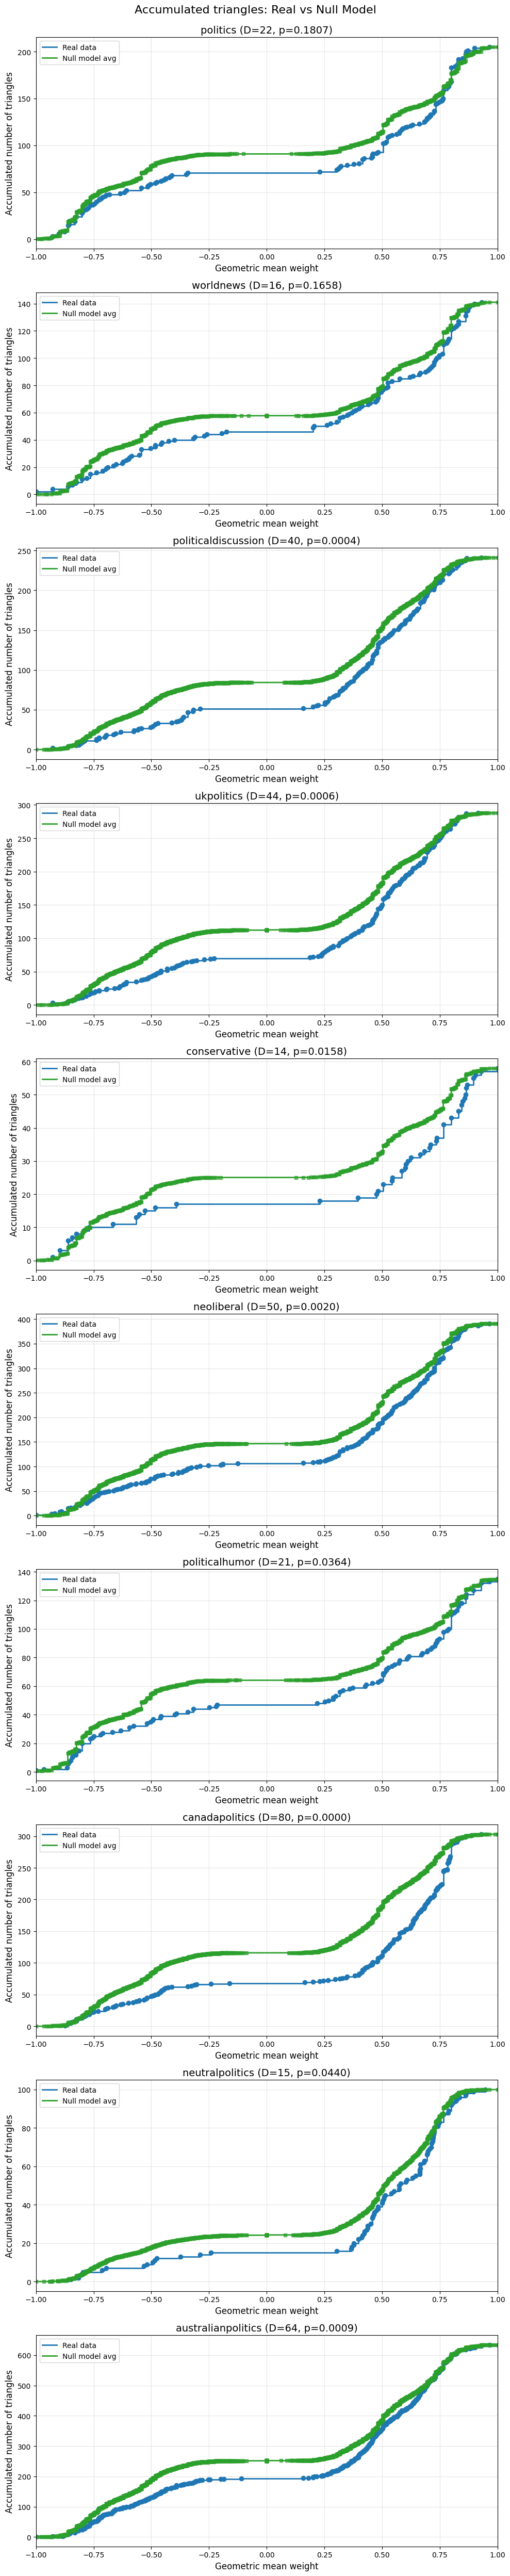


Kolmogorov-Smirnov Test Results:
politics                       | D =  22.0000 | p-value =   0.1807
worldnews                      | D =  16.0000 | p-value =   0.1658
politicaldiscussion            | D =  40.0000 | p-value =   0.0004
ukpolitics                     | D =  44.0000 | p-value =   0.0006
conservative                   | D =  14.0000 | p-value =   0.0158
neoliberal                     | D =  50.0000 | p-value =   0.0020
politicalhumor                 | D =  21.0000 | p-value =   0.0364
canadapolitics                 | D =  80.0000 | p-value =   0.0000
neutralpolitics                | D =  15.0000 | p-value =   0.0440
australianpolitics             | D =  64.0000 | p-value =   0.0009


In [11]:
kolmogorov_smirnov(triangles_graph, calculate_triangles_null_graph(graphs, null_models))